# CodeAlpha - TASK-4. Sales Prediction using Python

## 1.Import Required Libraries

In [1]:
# Import required libraries :

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries :

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2.Load Dataset

In [2]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 3.Dataset Overview

In [3]:
# Dataset overview :

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.info()
df.describe()

Shape: (200, 5)
Columns: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## 4.Data Cleaning

In [4]:
# Remove duplicates :
df = df.drop_duplicates()

# Fill missing values :
for col in df.select_dtypes(include = 'number'):
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include = 'object'):
    df[col] = df[col].fillna(df[col].mode()[0])

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 5.Exploratory Data Analysis (EDA)

### 1.Distribution analysis

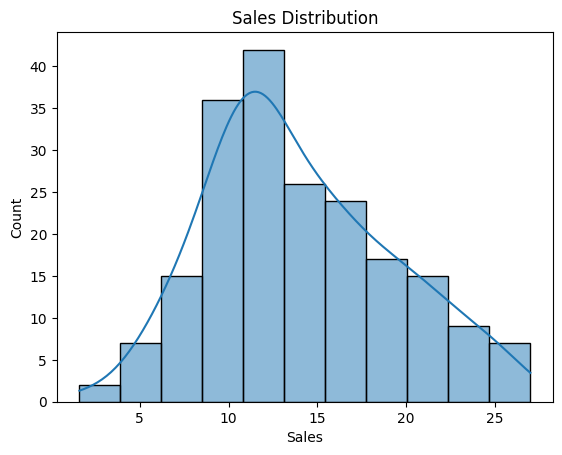

In [5]:
# Sales Distribution :

sns.histplot(df['Sales'], kde = True)
plt.title('Sales Distribution')

plt.show()

In [ ]:
# Result of Analysis :

# The sales distribution shows that most observations fall within
# a moderate sales range, while fewer records represent very high sales.
# This indicates that sales performance is concentrated around average values.

### 2.Advertising impact

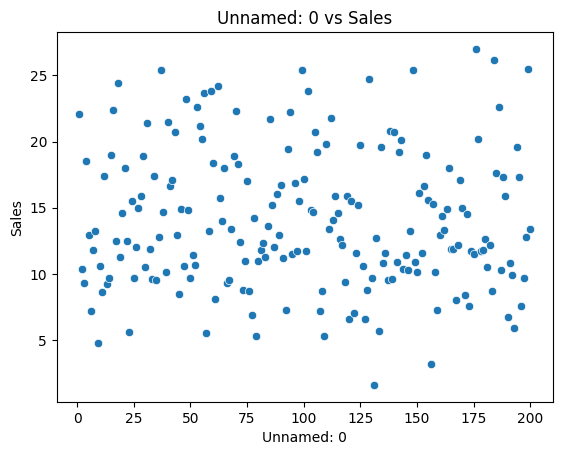

In [6]:
# Advertising impact :

sns.scatterplot(data = df, x = 'Unnamed: 0', y = 'Sales')
plt.title('Unnamed: 0 vs Sales')

plt.show()

In [ ]:
# Result of Analysis :

# Advertising expenditure shows a positive influence on sales.
# Higher advertising investment generally contributes to improved sales performance,
# although the impact differs across advertising channels.

### 3.Correlation 

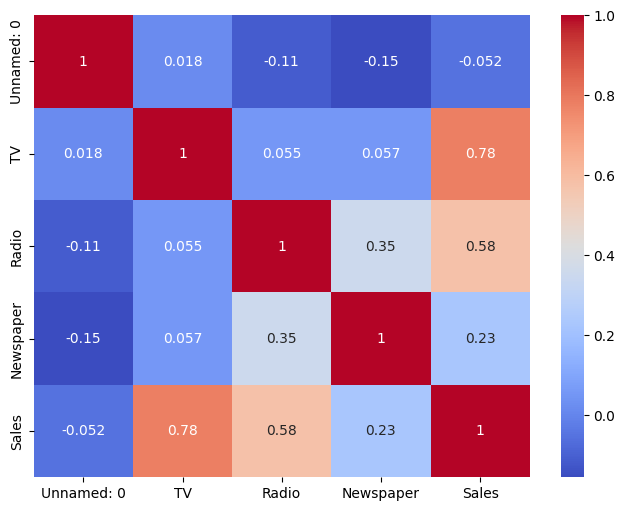

In [7]:
# Correlation heatmap :

plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only = True),annot = True,cmap = 'coolwarm')

plt.show()

In [ ]:
# Result of Analysis :

# The heatmap highlights relationships among variables and helps identify
# which advertising channels have stronger influence on sales.
# Stronger correlations indicate higher predictive importance.

## 6.Feature Selection

In [8]:
# Select input and target :
X = df.drop('Sales', axis = 1)
y = df['Sales']

# Encode categorical columns if present :
X = pd.get_dummies(X, drop_first = True)

In [ ]:
# Conclusion:

# Relevant features were selected to improve prediction quality
# and reduce unnecessary model complexity.

## 7.Model Building

In [9]:
# Split data :

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

models = {
    'Linear Regression':LinearRegression(),
    'Decision Tree':DecisionTreeRegressor(random_state = 42),
    'Random Forest':RandomForestRegressor(random_state = 42)
    }

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    trained[name] = model

    results.append([
        name,
        r2_score(y_test,pred),
        mean_absolute_error(y_test,pred),
        np.sqrt(mean_squared_error(y_test,pred))
    ])
 
result_df = pd.DataFrame(results,columns = ['Model','R2 Score','MAE','RMSE'])
result_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.898649,1.465060,1.788576
1,Decision Tree,0.944152,1.012500,1.327686
2,Random Forest,0.978490,0.670325,0.823979


In [ ]:
# Conclusion:

# Machine Learning models were trained to learn patterns between
# input variables and sales outcomes for future prediction.
# Evaluation metrics were used to measure model performance
# and determine prediction accuracy.

## 8.Sales Prediction

In [10]:
# Predict future sales using Random Forest :

sample = X.iloc[[0]]
prediction = trained['Random Forest'].predict(sample)
print('Predicted Sales:', round(prediction[0],2))

Predicted Sales: 21.98


In [ ]:
# Conclusion:

# The trained model predicted future sales values effectively,
# demonstrating the practical application of machine learning
# for business forecasting.

In [12]:
# Save cleaned dataset to a specific location :

save_path = r"D:\Internship\CodeAlpha\TASK_4\Outputs\cleaned_Advertising.csv"

df.to_csv(save_path, index = False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 9.Insights
1. Advertising spending affects sales.
2. Correlation helps identify important factors.
3. Random Forest may improve prediction accuracy.
4. Clean data improves performance.
5. Business decisions can be data-driven.

## 10.Conclusion
This project predicts future sales using regression techniques and supports business decision making.